# Parameter matching: 2d Gaussian mean

multi-$\theta$ transport realised as a single scalar potential trained for one fixed `LinearParameterPath`.  The trained $\phi$ is path-locked, meaning it is valid only for transport along the path it was trained on. The family is $p_\theta = \mathcal N(\theta, I)$, $\theta \in \mathbb R^2$, transported along the diagonal path $\theta(s) = (1-s)(0,0) + s(1,1)$.

The path-pinned loss projects the continuity-equation residual onto the path tangent $\dot\theta(s)$, collapsing the $d_\theta$-component vector PDE to one scalar equation in $s$. With this convention $\phi$ is the per-unit-$s$ potential, so transport integrates $\dot x = \nabla_x\phi$ with no $\dot\theta$ scaling (which contrasts the dim-1 loss of the linear-titled example, where $\phi$ is per-unit-$\theta$ and transport scales by $\dot\theta$).

In [13]:
import torch
import matplotlib.pyplot as plt
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')

from nami import (
    RK4,
    LinearParameterPath,
    OracleScore,
    ParameterFlow,
    ScalarPotentialField,
    path_pinned_parameter_flow_loss,
)

torch.manual_seed(11)
generator = torch.Generator().manual_seed(11)

theta_0 = torch.tensor([0.0, 0.0])
theta_1 = torch.tensor([1.0, 1.0])
path = LinearParameterPath(theta_0, theta_1)

delta = theta_1 - theta_0  # the analytic per-unit-s velocity (constant)

### Closed-form scores for $\mathcal N(\theta, I)$

- Joint score $\partial_\theta \log p = x - \theta$ (per component)

- spatial score $\nabla_x \log p = \theta - x$.  

In [14]:
def joint_score(x, theta):
    return x - theta  # (*lead, d_theta)


def spatial_score(x, theta):
    return theta - x  # (*lead, d_x)


joint = OracleScore(joint_score)
spatial = OracleScore(spatial_score)

## Train $\phi$ on the path-pinned residual

`s ~ U(0,1)`, `x ~ N(theta(s), I)`.  

The analytic per-unit-$s$ potential is $\phi = (\theta_1-\theta_0)\cdot x$, giving $\nabla\phi = \dot\theta$ constant
and $\Delta\phi = 0$. The residual vanishes identically.

step 0: loss 1.945e+00
step 500: loss 1.476e-05
step 1000: loss 3.812e-06
step 1500: loss 3.790e-06
step 2000: loss 1.096e-06
step 2500: loss 1.489e-06


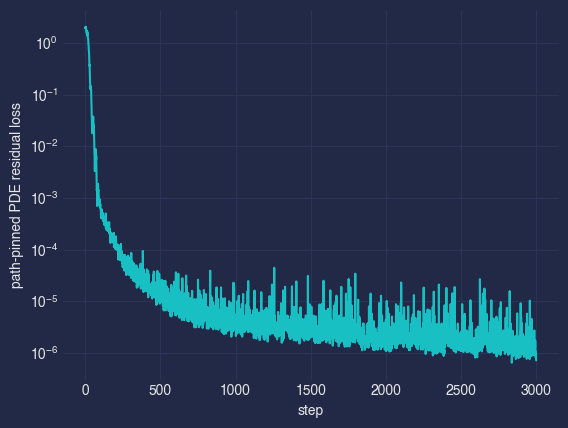

In [15]:
field = ScalarPotentialField(2, theta_dim=2, hidden=64, layers=3)
optimizer = torch.optim.Adam(field.parameters(), lr=1e-3)
losses = []
for step in range(3000):
    s = torch.rand(512, generator=generator)
    theta_s = path.theta(s)
    x = theta_s + torch.randn(512, 2, generator=generator)
    loss = path_pinned_parameter_flow_loss(
        field, x=x, s=s, path=path, joint_score=joint, spatial_score=spatial
    )
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if step % 500 == 0:
        print(f'step {step}: loss {loss.item():.3e}')

plt.semilogy(losses)
plt.xlabel('step')
plt.ylabel('path-pinned PDE residual loss')
plt.show()

### $\nabla\phi$ vs the analytic velocity at held-out $s$

The recovered velocity must match the constant $\dot\theta = (1,1)$ in
$p_{\theta(s)}$-weighted $L^2$ below $10^{-3}$ at $s \in \{0.25, 0.5, 0.75\}$.

In [16]:
for s_eval in (0.25, 0.5, 0.75):
    s_t = torch.full((4096,), s_eval)
    theta_s = path.theta(s_t)
    x = theta_s + torch.randn(4096, 2, generator=generator)
    v_model = field.velocity(x, theta_s, create_graph=False)
    v_true = delta.expand_as(v_model)
    err = (v_model - v_true).pow(2).sum(-1).mean()
    print(f's={s_eval}: p-weighted L2 velocity err {err.item():.3e}')
    assert err.item() < 1e-3

s=0.25: p-weighted L2 velocity err 2.316e-07
s=0.5: p-weighted L2 velocity err 3.675e-07
s=0.75: p-weighted L2 velocity err 3.863e-07


### transport $\mathcal N(\theta_0, I) \to \mathcal N(\theta_1, I)$

Here, we bind the same path (a $d_\theta>1$ path selects pinned mode automatically) and integrate $\dot x = \nabla_x\phi$ directly, such that there's no $\dot\theta$ scaling. The transported cloud must overlay fresh truth samples at $\theta_1$.

transported mean [0.9872039556503296, 0.9937736392021179] target [1.0, 1.0]
transported var  [0.9879928231239319, 1.0044856071472168] target [1.0, 1.0]


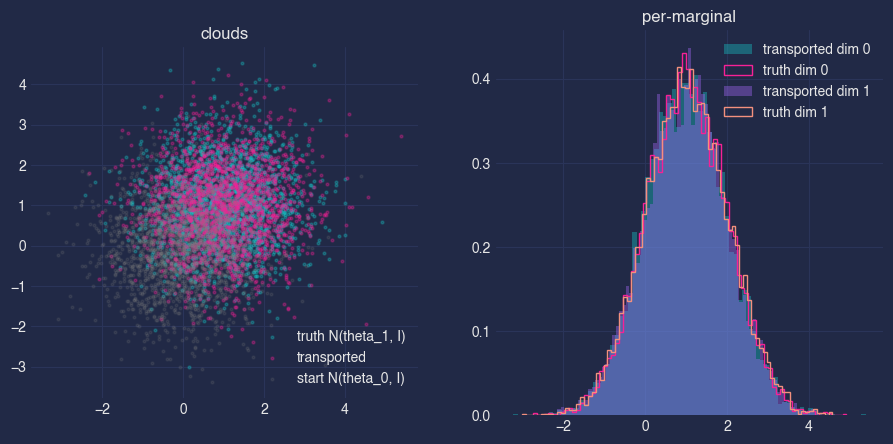

In [17]:
process = ParameterFlow(field, RK4(steps=64))(path)
assert process.pinned is True

n = 8192
x0 = theta_0 + torch.randn(n, 2, generator=generator)
with torch.no_grad():
    x1 = process.transport(x0)
truth = theta_1 + torch.randn(n, 2, generator=generator)

print('transported mean', x1.mean(0).tolist(), 'target', theta_1.tolist())
print('transported var ', x1.var(0).tolist(), 'target [1.0, 1.0]')

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].scatter(truth[:2000, 0], truth[:2000, 1], s=4, alpha=0.3, label='truth N(theta_1, I)')
ax[0].scatter(x1[:2000, 0], x1[:2000, 1], s=4, alpha=0.3, label='transported')
ax[0].scatter(x0[:2000, 0], x0[:2000, 1], s=4, alpha=0.15, color='grey', label='start N(theta_0, I)')
ax[0].legend(); ax[0].set_aspect('equal'); ax[0].set_title('clouds')
for d in range(2):
    ax[1].hist(x1[:, d].numpy(), bins=80, density=True, alpha=0.4, label=f'transported dim {d}')
    ax[1].hist(truth[:, d].numpy(), bins=80, density=True, histtype='step', label=f'truth dim {d}')
ax[1].legend(); ax[1].set_title('per-marginal')
plt.show()

### sample checks: energy distance and per-marginal KS

These statistics are implemented inline (i.e. no use of scipy right now, just custom): 

- energy distance against fresh truth samples, and
- per-dimension two-sample Kolmogorov-Smirnov statistic.

In [18]:
def energy_distance(a, b):
    md = lambda u, v: torch.cdist(u, v).mean()
    return 2 * md(a, b) - md(a, a) - md(b, b)


def ks_statistic(a, b):
    a_s, b_s = torch.sort(a)[0], torch.sort(b)[0]
    grid = torch.cat([a_s, b_s])
    ca = torch.searchsorted(a_s, grid, right=True).float() / a.numel()
    cb = torch.searchsorted(b_s, grid, right=True).float() / b.numel()
    return (ca - cb).abs().max()


ed = energy_distance(x1[:2048], truth[:2048])
ed_ref = energy_distance(truth[:2048], theta_1 + torch.randn(2048, 2, generator=generator))
print(f'energy distance transported-vs-truth {ed.item():.3e} '
      f'(truth-vs-truth reference {ed_ref.item():.3e})')
for d in range(2):
    print(f'dim {d}: KS statistic {ks_statistic(x1[:, d], truth[:, d]).item():.3e}')

energy distance transported-vs-truth 2.170e-03 (truth-vs-truth reference 1.213e-03)
dim 0: KS statistic 1.685e-02
dim 1: KS statistic 1.306e-02


### why a pointwise Frobenius check is vacuous here

Frobenius (integrability) compatibility asks whether
$\partial_i \nabla\phi^j = \partial_j \nabla\phi^i$ *across* $\theta$-directions
— it needs a potential defined over an open $\theta$-region.  A path-pinned
$\phi$ is trained on the one-dimensional path slice only; it has no second
$\theta$-direction to commute against, so the cross-derivative condition is not
even defined for it.  The single trained object is, by construction, path-locked
— checking Frobenius on it is vacuous.

The genuine multi-path question — *does the transported endpoint depend on the
path chosen between the same $\theta_0, \theta_1$?* — is real curvature
(holonomy) for $\dim\Theta \ge 2$, not a gauge artefact, and is the deferred
**group-consistency loss / holonomy diagnostic** research line, not a property
of any one pinned potential.

## A curved potential

Everything above was verified on a family whose analytic solution is
**degenerate**: for the Gaussian-mean family, $\phi = \dot\theta\cdot x$, so the
velocity is constant, $\Delta_x\phi = 0$, and the elliptic term and coupling
term of the pinned PDE vanish identically.  The machinery passed — but on an
instance where the PDE is trivially satisfied.

M2.5 closes the *machinery vs expressiveness* gap with the **anisotropic
variance family**

$$p_\theta(x) = \mathcal{N}(0, \mathrm{diag}(\theta)),\qquad
\theta = (\theta_1, \theta_2) \in \mathbb{R}^2_+ \;\text{(variances)},$$

along a pinned path where one dimension **inflates** and the other
**shrinks**: $\theta^0 = (1, 1) \to \theta^1 = (2.25, 0.49)$.  Still fully
analytic, but nothing is trivial:

$$\text{joint}_i = -\tfrac{1}{2\theta_i} + \tfrac{x_i^2}{2\theta_i^2},\quad
\text{spatial}_i = -\tfrac{x_i}{\theta_i},\quad
\phi = \sum_i \tfrac{\Delta_i x_i^2}{4\theta_i(s)}$$

so the velocity $v_i = \Delta_i x_i / 2\theta_i(s)$ is **$x$-dependent**, the
Laplacian $\sum_i \Delta_i/2\theta_i(s)$ is **non-zero**, and the three PDE
terms cancel *against each other* rather than each being zero.  Bonus: the
endpoint transport map is exactly affine, $x_i \mapsto x_i\sqrt{\theta_i^1 /
\theta_i^0} = (1.5\,x_1,\; 0.7\,x_2)$ — a **sample-wise** check, stronger
than any two-sample test.


step 0: loss 4.721e-01
step 1000: loss 7.728e-04
step 2000: loss 8.339e-05
step 3000: loss 3.356e-05


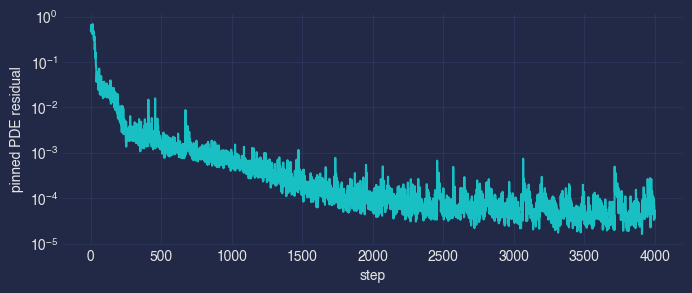

In [19]:
VAR_0 = torch.tensor([1.0, 1.0])
VAR_1 = torch.tensor([2.25, 0.49])
var_path = LinearParameterPath(VAR_0, VAR_1)


def var_joint_score(x, theta):
    return -1.0 / (2 * theta) + x.pow(2) / (2 * theta.pow(2))


def var_spatial_score(x, theta):
    return -x / theta


def var_velocity(x, theta):
    return (VAR_1 - VAR_0) * x / (2 * theta)


torch.manual_seed(11)
gen25 = torch.Generator().manual_seed(11)
field25 = ScalarPotentialField(2, theta_dim=2, hidden=64, layers=3)
opt25 = torch.optim.Adam(field25.parameters(), lr=1e-3)
losses25 = []
for step in range(4000):
    s = torch.rand(512, generator=gen25)
    theta_s = var_path.theta(s)
    x = theta_s.sqrt() * torch.randn(512, 2, generator=gen25)
    loss = path_pinned_parameter_flow_loss(
        field25,
        x=x,
        s=s,
        path=var_path,
        joint_score=OracleScore(var_joint_score),
        spatial_score=OracleScore(var_spatial_score),
    )
    opt25.zero_grad()
    loss.backward()
    opt25.step()
    losses25.append(loss.item())
    if step % 1000 == 0:
        print(f"step {step}: loss {loss.item():.3e}")

plt.figure(figsize=(8, 3))
plt.semilogy(losses25)
plt.xlabel("step")
plt.ylabel("pinned PDE residual")
plt.show()


### The recovered velocity field is genuinely curved

Unlike the constant shift above, the trained $\nabla\phi$ must now vary over $x$: outward along $x_1$ (inflating), inward along $x_2$ (shrinking).


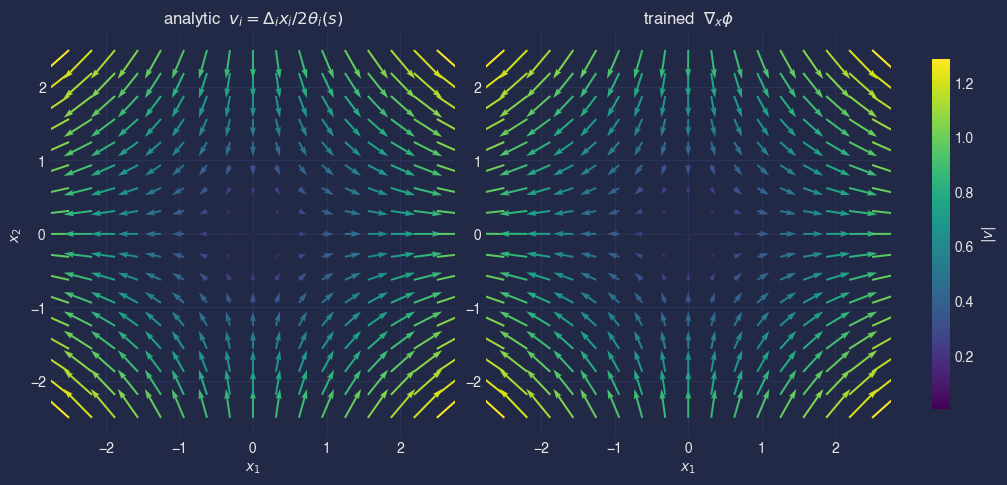

In [20]:
s_show = 0.5
theta_show = var_path.theta(torch.tensor([s_show]))[0]
g = torch.linspace(-2.5, 2.5, 17)
gx, gy = torch.meshgrid(g, g, indexing="xy")
pts = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=-1)
th = theta_show.expand(pts.shape[0], 2)

v_model = field25.velocity(pts, th, create_graph=False).detach()
v_true = var_velocity(pts, th)
err = (v_model - v_true).norm(dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), layout="constrained")
for ax, v, title in (
    (axes[0], v_true, "analytic  $v_i = \\Delta_i x_i / 2\\theta_i(s)$"),
    (axes[1], v_model, "trained  $\\nabla_x \\phi$"),
):
    q = ax.quiver(
        pts[:, 0], pts[:, 1], v[:, 0], v[:, 1],
        v.norm(dim=-1), cmap="viridis", scale=12, width=0.005,
    )
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.colorbar(q, ax=axes, label="$|v|$", shrink=0.85)
plt.show()


### Sample-wise verification against the exact affine map


sample-wise RMS vs exact map (1.5 x1, 0.7 x2): 4.755e-03
transported std [1.488876223564148, 0.6970133781433105]  target [1.5, 0.699999988079071]


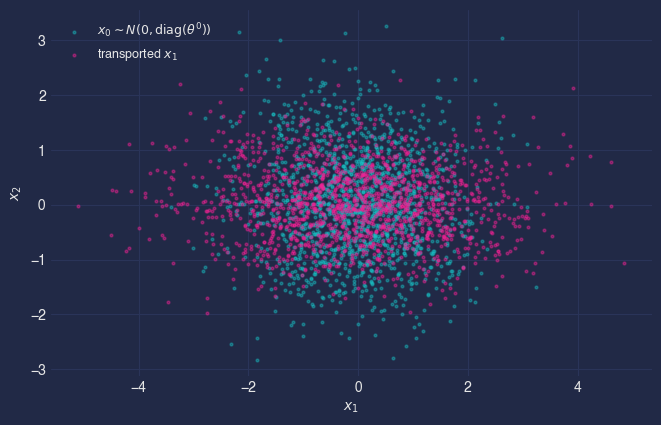

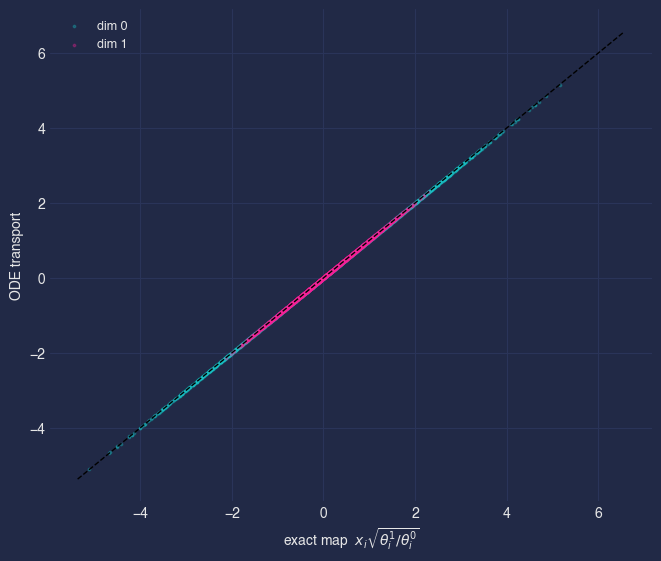

In [21]:
process25 = ParameterFlow(field25, RK4(steps=64))(var_path)
n = 8192
x0 = VAR_0.sqrt() * torch.randn(n, 2, generator=gen25)
x1 = process25.transport(x0)
exact = x0 * (VAR_1 / VAR_0).sqrt()

rms = (x1 - exact).pow(2).sum(-1).mean().sqrt()
print(f"sample-wise RMS vs exact map (1.5 x1, 0.7 x2): {rms:.3e}")
print(f"transported std {x1.std(0).tolist()}  target {(VAR_1.sqrt()).tolist()}")

fig, ax = plt.subplots(figsize=(6.5, 6.5), layout="constrained")
ax.scatter(
    x0[:1500, 0],
    x0[:1500, 1],
    s=4,
    alpha=0.4,
    label=r"$x_0 \sim N(0, \mathrm{diag}(\theta^0))$",
)
ax.scatter(x1[:1500, 0], x1[:1500, 1], s=4, alpha=0.4, label="transported $x_1$")
ax.set_aspect("equal")
ax.legend(fontsize=9)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5), layout="constrained")
ax.scatter(exact[:3000, 0], x1[:3000, 0], s=3, alpha=0.3, label="dim 0")
ax.scatter(exact[:3000, 1], x1[:3000, 1], s=3, alpha=0.3, label="dim 1")
lims = [exact.min().item(), exact.max().item()]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("exact map  $x_i\\sqrt{\\theta_i^1/\\theta_i^0}$")
ax.set_ylabel("ODE transport")
ax.legend(fontsize=9)
plt.show()
